=== EXERCISE 1 (30 Features) ===
Accuracy: 0.9298
Misclassified: 233/3317

=== EXERCISE 2 (2 Features: PrefixSuffix & AnchorURL) ===
Accuracy: 0.8444
Misclassified: 516/3317
Accuracy Drop: 0.0853



c:\Users\SETUP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


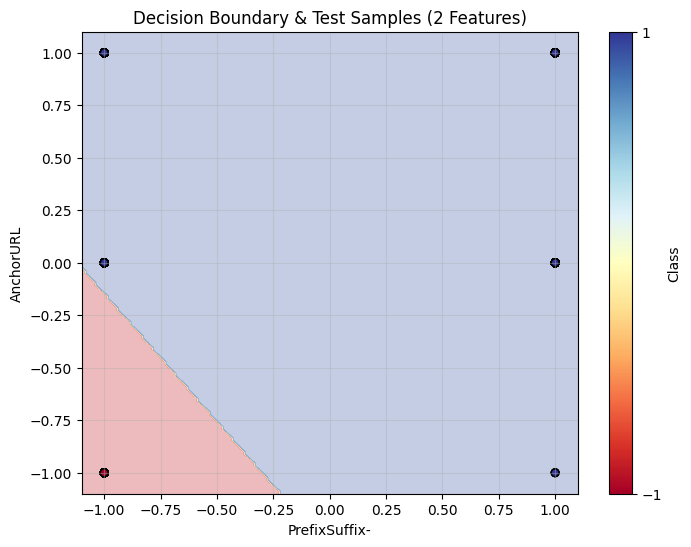

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Load & Prepare Data
headers = [
    'Using_IP', 'Long_URL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-',
    'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL',
    'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail',
    'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick',
    'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording',
    'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport', 'class'
]

df = pd.read_csv('phishing_dataset.txt', header=None, sep=',') # Change sep if needed
df.columns = headers

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Exercise 1: Full Feature Model
lr_full = LogisticRegression(C=100, random_state=42, max_iter=1000)
lr_full.fit(X_train, y_train)

y_pred_full = lr_full.predict(X_test)
acc_full = accuracy_score(y_test, y_pred_full)
mis_full = (y_test != y_pred_full).sum()

print("=== EXERCISE 1 (30 Features) ===")
print(f"Accuracy: {acc_full:.4f}")
print(f"Misclassified: {mis_full}/{len(y_test)}\n")

# 3. Exercise 2: Two-Feature Model
X_train_2 = X_train.iloc[:, [5, 13]]
X_test_2 = X_test.iloc[:, [5, 13]]

lr_two = LogisticRegression(C=100, random_state=42, max_iter=1000)
lr_two.fit(X_train_2, y_train)

y_pred_2 = lr_two.predict(X_test_2)
acc_2 = accuracy_score(y_test, y_pred_2)
mis_2 = (y_test != y_pred_2).sum()

print("=== EXERCISE 2 (2 Features: PrefixSuffix & AnchorURL) ===")
print(f"Accuracy: {acc_2:.4f}")
print(f"Misclassified: {mis_2}/{len(y_test)}")
print(f"Accuracy Drop: {acc_full - acc_2:.4f}\n")

# 4. Decision Boundary Plot
x_min, x_max = X_test_2.iloc[:, 0].min()-0.1, X_test_2.iloc[:, 0].max()+0.1
y_min, y_max = X_test_2.iloc[:, 1].min()-0.1, X_test_2.iloc[:, 1].max()+0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = lr_two.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
sc = plt.scatter(X_test_2.iloc[:, 0], X_test_2.iloc[:, 1], c=y_test, 
                 edgecolor='k', cmap='RdYlBu', s=30)
plt.colorbar(sc, ticks=[-1, 1], label='Class')
plt.xlabel('PrefixSuffix-')
plt.ylabel('AnchorURL')
plt.title('Decision Boundary & Test Samples (2 Features)')
plt.grid(True, alpha=0.4)
plt.show()